### 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 2. Load and Prepare Data

In [2]:
df = pd.read_csv(
    '../data/raw/household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)

In [3]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

In [4]:
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [5]:
df = df.apply(pd.to_numeric)
df.interpolate(method='time', inplace=True)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0


In [6]:
energy_hourly = df['Global_active_power'].resample('h').mean()
energy_hourly.interpolate(method='time', inplace=True)

datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
                         ...   
2010-11-26 17:00:00    1.725900
2010-11-26 18:00:00    1.573467
2010-11-26 19:00:00    1.659333
2010-11-26 20:00:00    1.163700
2010-11-26 21:00:00    0.934667
Freq: h, Name: Global_active_power, Length: 34589, dtype: float64

### 3. Data Formatting for Prophet

In [7]:
prophet_df = energy_hourly.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_df

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467
...,...,...
34584,2010-11-26 17:00:00,1.725900
34585,2010-11-26 18:00:00,1.573467
34586,2010-11-26 19:00:00,1.659333
34587,2010-11-26 20:00:00,1.163700


### 4. Train-Test Split

In [8]:
train_size = int(len(prophet_df) * 0.9)

train = prophet_df[:train_size]
test = prophet_df[train_size:]

### 5. Prophet Model Training

Prophet is used to model time series data with strong seasonality and trend components. It automatically handles daily and weekly seasonality.

In [9]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

21:46:53 - cmdstanpy - INFO - Chain [1] start processing
21:46:59 - cmdstanpy - INFO - Chain [1] done processing


### 6. Forecast Generation

In [10]:
future = model.make_future_dataframe(periods=len(test), freq='h')
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2006-12-16 17:00:00,1.399512,0.860709,2.725978,1.399512,1.399512,0.393381,0.393381,0.393381,-0.075798,...,0.170849,0.170849,0.170849,0.298329,0.298329,0.298329,0.0,0.0,0.0,1.792893
1,2006-12-16 18:00:00,1.399380,1.225392,3.057036,1.399380,1.399380,0.755424,0.755424,0.755424,0.278551,...,0.178292,0.178292,0.178292,0.298581,0.298581,0.298581,0.0,0.0,0.0,2.154804
2,2006-12-16 19:00:00,1.399248,1.649937,3.495522,1.399248,1.399248,1.169555,1.169555,1.169555,0.685618,...,0.185103,0.185103,0.185103,0.298834,0.298834,0.298834,0.0,0.0,0.0,2.568803
3,2006-12-16 20:00:00,1.399116,1.857649,3.705956,1.399116,1.399116,1.369142,1.369142,1.369142,0.878827,...,0.191226,0.191226,0.191226,0.299089,0.299089,0.299089,0.0,0.0,0.0,2.768258
4,2006-12-16 21:00:00,1.398984,1.674039,3.528698,1.398984,1.398984,1.216005,1.216005,1.216005,0.720054,...,0.196607,0.196607,0.196607,0.299344,0.299344,0.299344,0.0,0.0,0.0,2.614989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34584,2010-11-26 17:00:00,1.117290,0.380112,2.268491,1.060302,1.171832,0.253907,0.253907,0.253907,-0.075798,...,-0.045299,-0.045299,-0.045299,0.375004,0.375004,0.375004,0.0,0.0,0.0,1.371197
34585,2010-11-26 18:00:00,1.117293,0.809977,2.668826,1.060286,1.171856,0.614545,0.614545,0.614545,0.278551,...,-0.038876,-0.038876,-0.038876,0.374870,0.374870,0.374870,0.0,0.0,0.0,1.731838
34586,2010-11-26 19:00:00,1.117296,1.199495,3.105940,1.060269,1.171879,1.028286,1.028286,1.028286,0.685618,...,-0.032064,-0.032064,-0.032064,0.374732,0.374732,0.374732,0.0,0.0,0.0,2.145582
34587,2010-11-26 20:00:00,1.117300,1.343259,3.304956,1.060253,1.171902,1.228554,1.228554,1.228554,0.878827,...,-0.024865,-0.024865,-0.024865,0.374591,0.374591,0.374591,0.0,0.0,0.0,2.345854


- yhat → prediction
- yhat_lower → lower bound
- yhat_upper → upper bound

### 7. Forecast Visualization

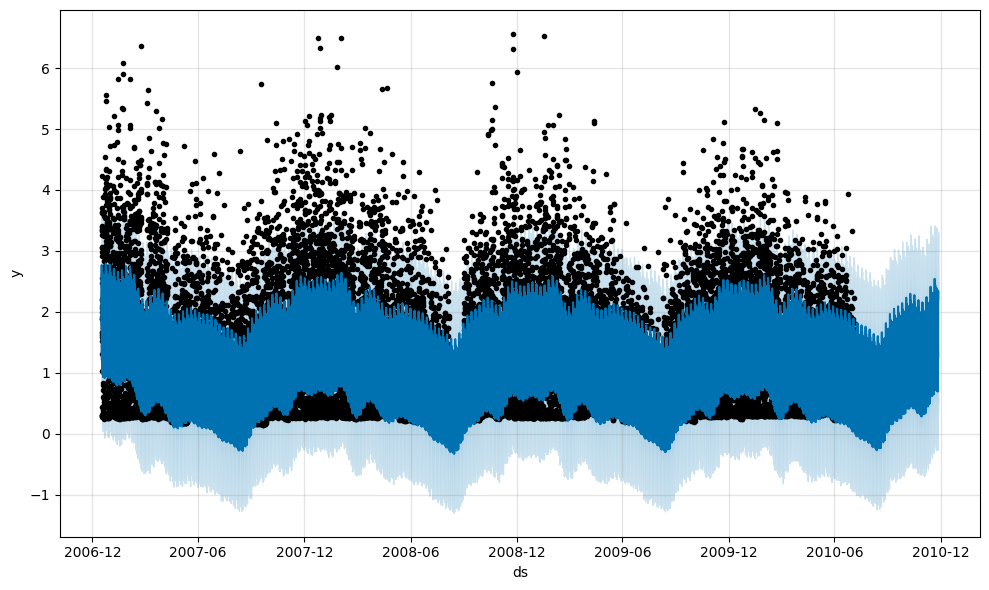

In [11]:
model.plot(forecast); 

- Black dots → actual
- Blue line → prediction
- Light blue → confidence interval

### 8. Components Analysis (Trend & Seasonality)

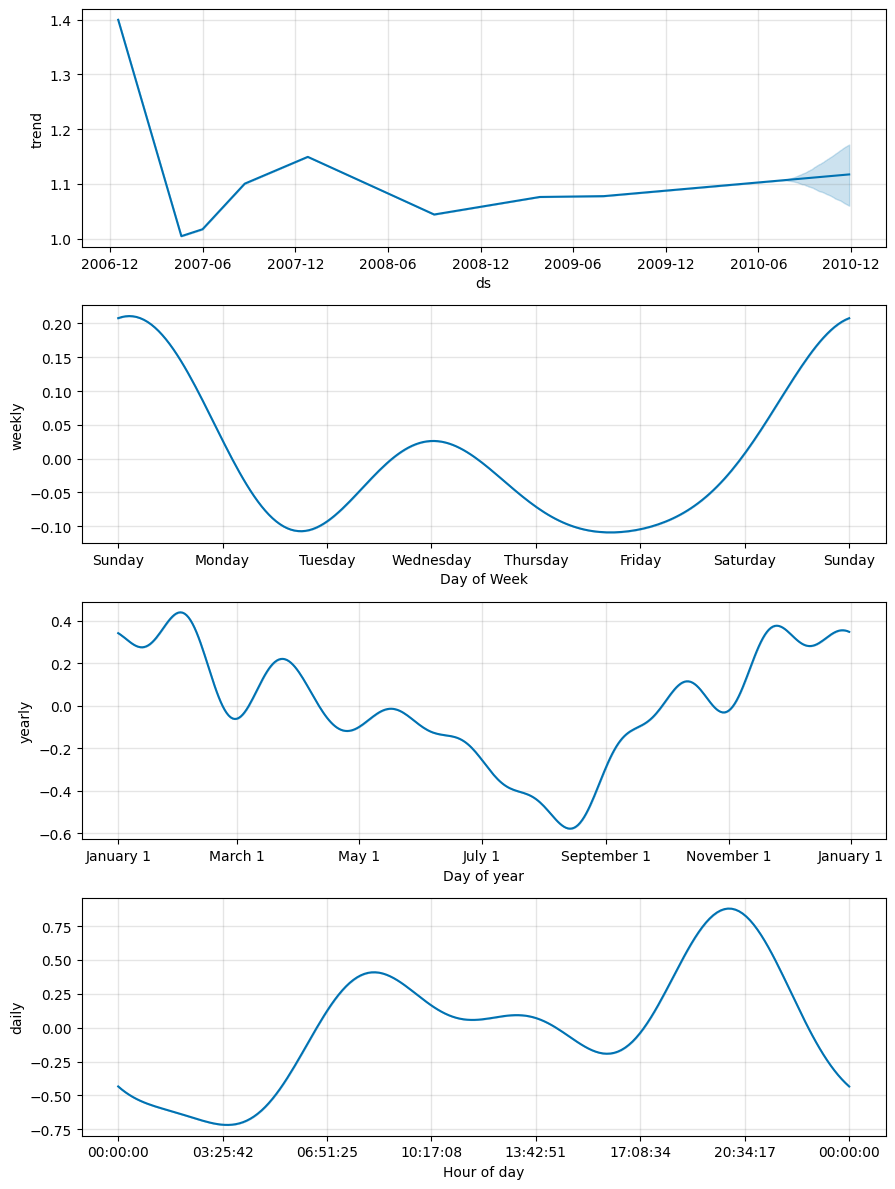

In [12]:
model.plot_components(forecast);

### 9. Model Evaluation Strategy

- The model is evaluated using a train-test split (90%-10%).  
- Performance is measured using MAE, RMSE, and MAPE.  
- A 24-hour forecast is also generated for short-term evaluation.

### 10. Model Evaluation (MAE, RMSE, MAPE)

In [13]:
forecast_test = forecast.iloc[-len(test):]

mae = mean_absolute_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))

print("MAE :", mae)
print("RMSE:", rmse)

def mape(y_true, y_pred):
    return (abs((y_true - y_pred) / y_true).mean()) * 100

mape_value = mape(test['y'], forecast_test['yhat'])
print("MAPE:", mape_value)

MAE : 0.49337950448162626
RMSE: 0.6395071663668623
MAPE: 81.67576382191334


The Prophet model was evaluated using MAE and RMSE.

- MAE measures average error magnitude
- RMSE penalizes larger errors more heavily
- MAPE provides a percentage-based error metric for better interpretability.

The results indicate that the model captures overall trends and seasonality effectively.

### 11. Hyperparameter Tuning

- Hyperparameter tuning was performed to improve model performance by adjusting key parameters of the Prophet model.
- The parameter `changepoint_prior_scale` controls the flexibility of the trend. A higher value allows the model to adapt more quickly to changes in the data.

In [14]:
# Default model (already trained earlier)
mae_default = mae
rmse_default = rmse

# Tuned model
model_tuned = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.5
)

model_tuned.fit(train)

future = model_tuned.make_future_dataframe(periods=len(test), freq='h')
forecast_tuned = model_tuned.predict(future)

forecast_test_tuned = forecast_tuned.iloc[-len(test):]

mae_tuned = mean_absolute_error(test['y'], forecast_test_tuned['yhat'])
rmse_tuned = np.sqrt(mean_squared_error(test['y'], forecast_test_tuned['yhat']))

print("Default MAE :", mae_default)
print("Tuned MAE   :", mae_tuned)

print("Default RMSE:", rmse_default)
print("Tuned RMSE  :", rmse_tuned)

21:47:04 - cmdstanpy - INFO - Chain [1] start processing
21:47:12 - cmdstanpy - INFO - Chain [1] done processing


Default MAE : 0.49337950448162626
Tuned MAE   : 0.49802512738165655
Default RMSE: 0.6395071663668623
Tuned RMSE  : 0.641550976773326


### Hyperparameter Tuning Results

The tuned model was compared with the default configuration.

- Default MAE: 0.493  
- Tuned MAE: 0.498  
- Default RMSE: 0.639  
- Tuned RMSE: 0.642  

The tuned model showed slightly higher error compared to the default configuration.

This indicates that the default Prophet parameters are already well-suited for this dataset and provide better generalization.

This experiment highlights that hyperparameter tuning does not always guarantee improved performance and must be validated using proper evaluation metrics.

Prophet’s default configuration is often robust for datasets with clear seasonality, reducing the need for extensive tuning.

### 12. Residual Analysis

- Residuals appear randomly distributed around zero, indicating that the model has captured most of the underlying patterns in the data.
- No clear patterns or trends are observed, suggesting good model performance.

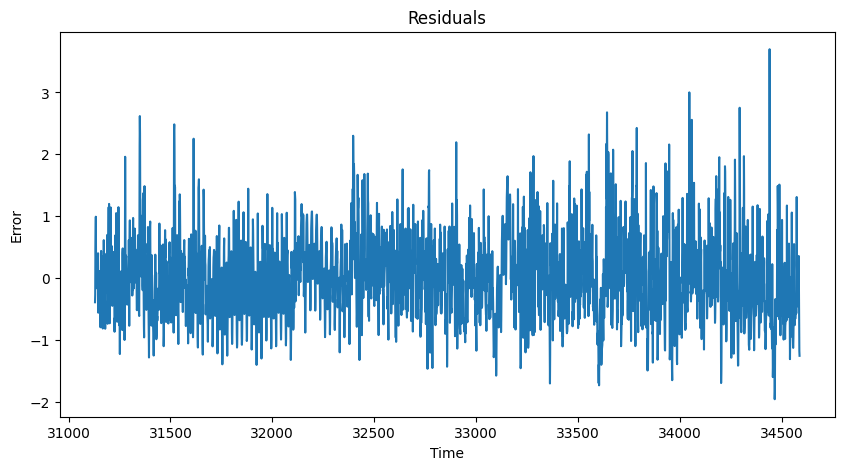

In [15]:
residuals = test['y'] - forecast_test['yhat']

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title('Residuals')
plt.xlabel('Time')
plt.ylabel('Error')
plt.show()

### 13. Walk-Forward Validation

A simple walk-forward validation approach was implemented by training the model on historical data and forecasting the next 24 hours.

This helps evaluate how well the model generalizes to unseen future data.

In [16]:
train_small = prophet_df[:-24]
test_small = prophet_df[-24:]

model = Prophet(daily_seasonality=True, weekly_seasonality=True)
model.fit(train_small)

future = model.make_future_dataframe(periods=24, freq='h')
forecast = model.predict(future)

pred = forecast[['ds','yhat']].tail(24)

mae_wf = mean_absolute_error(test_small['y'], pred['yhat'])
print("Walk-forward MAE:", mae_wf)

21:47:17 - cmdstanpy - INFO - Chain [1] start processing
21:47:26 - cmdstanpy - INFO - Chain [1] done processing


Walk-forward MAE: 0.3954184598376349


In [17]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
34565,2010-11-25 22:00:00,1.617157,0.721194,2.572800
34566,2010-11-25 23:00:00,1.190685,0.261677,2.116318
34567,2010-11-26 00:00:00,0.910777,-0.002968,1.841944
34568,2010-11-26 01:00:00,0.785602,-0.178182,1.697469
34569,2010-11-26 02:00:00,0.717959,-0.209800,1.637080
34570,2010-11-26 03:00:00,0.651645,-0.336947,1.612431
34571,2010-11-26 04:00:00,0.646728,-0.311421,1.543156
34572,2010-11-26 05:00:00,0.806905,-0.034464,1.828009
34573,2010-11-26 06:00:00,1.140471,0.220228,2.079802
34574,2010-11-26 07:00:00,1.507846,0.615846,2.445203


### 14. 24-Hour Forecast Output

In [18]:
future_24 = model.make_future_dataframe(periods=24, freq='h')
forecast_24 = model.predict(future_24)

forecast_24[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
34565,2010-11-25 22:00:00,1.617157,0.663494,2.580409
34566,2010-11-25 23:00:00,1.190685,0.249915,2.056570
34567,2010-11-26 00:00:00,0.910777,-0.044860,1.824397
34568,2010-11-26 01:00:00,0.785602,-0.168684,1.702603
34569,2010-11-26 02:00:00,0.717959,-0.207759,1.662784
34570,2010-11-26 03:00:00,0.651645,-0.282500,1.629386
34571,2010-11-26 04:00:00,0.646728,-0.222814,1.565958
34572,2010-11-26 05:00:00,0.806905,-0.153690,1.712923
34573,2010-11-26 06:00:00,1.140471,0.235114,2.069751
34574,2010-11-26 07:00:00,1.507846,0.592060,2.477439


### 15. Key Observations

- Prophet effectively captures daily and weekly seasonality.
- The model provides uncertainty intervals, which are useful for decision-making.
- Forecasts align well with historical trends.